<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 12.1</h1>

### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

### Deep Neural Network Classification

The aim of this exercise is to train a Deep Neural Network to classify handwritten digits from the MNIST dataset and to investigate the effect of different optimizers on the training and validation performance. In particular, the network is trained using SGD, Adam, and RMSprop, and their performances are compared in terms of accuracy and loss as a function of the number of epochs.

The MNIST images are first flattened from $28\times28$ pixels into vectors of $784$ input features and normalized to the range $[0,1]$. The labels are converted into categorical vectors using one-hot encoding. The DNN implemented through the function `create_DNN()` consists of an input layer, two fully connected hidden layers with $400$ and $100$ neurons respectively, both using the ReLU activation function, followed by a Dropout layer with probability $0.5$ to reduce overfitting and a final output layer with $10$ neurons, corresponding to the ten possible digits. 

The model is trained by minimizing the categorical cross-entropy loss, using a batch size of $32$ and $40$ epochs. The function `compile_model()` allows the same network architecture to be independently compiled with the three optimizers considered: SGD, Adam, and RMSprop. During training, both the accuracy and loss are monitored on the training and validation datasets, allowing the convergence and generalization properties of the different optimizers to be compared.

Finally, the trained models are evaluated on the test set and the predictions are inspected both on randomly selected images and on a set of misclassified digits.

In [20]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import SGD, Adam, RMSprop
import pandas as pd

In [2]:
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
from keras.datasets import mnist

# Input image dimensions
img_rows, img_cols = 28, 28

# Number of classes
num_classes = 10

# Load MNIST dataset
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_test shape: (10000, 28, 28)
Y_test shape: (10000,)


In [4]:
# Flatten images
X_train = X_train.reshape(X_train.shape[0], img_rows * img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows * img_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [5]:
# Convert to float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Rescale pixel values to [0, 1]
X_train /= 255.0
X_test /= 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Example label: 3


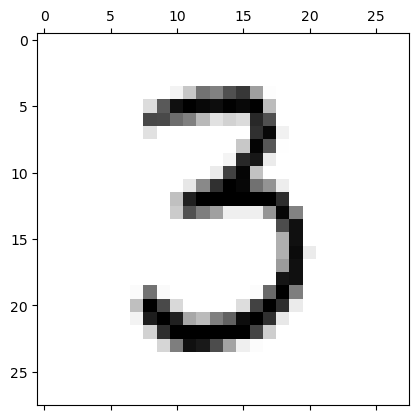

In [6]:
print("Example label:", Y_train[50])

plt.matshow(X_train[50].reshape(28, 28), cmap="binary")
plt.show()

In [7]:
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Y_train shape: (60000, 10)
Y_test shape: (10000, 10)


In [8]:
def create_DNN():
    model = Sequential()

    # Input layer
    model.add(Input(shape=(img_rows * img_cols,)))

    # First hidden layer
    model.add(Dense(400, activation="relu"))

    # Second hidden layer
    model.add(Dense(100, activation="relu"))

    # Dropout for regularization
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(num_classes, activation="softmax"))

    return model

In [9]:
model = create_DNN()
model.summary()

E0000 00:00:1787524640.396635 1583336 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def compile_model(optimizer):
    model = create_DNN()

    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [11]:
batch_size = 32
epochs = 40

In [12]:
model_SGD = compile_model(SGD())
model_Adam = compile_model(Adam())
model_RMSprop = compile_model(RMSprop())

In [13]:
history_SGD = model_SGD.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    verbose=1,
    validation_data=(X_test, Y_test)
)

Epoch 1/40


W0000 00:00:1787524641.066901 1583336 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.7746 - loss: 0.7626 - val_accuracy: 0.9148 - val_loss: 0.3157
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8911 - loss: 0.3833 - val_accuracy: 0.9299 - val_loss: 0.2414
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9129 - loss: 0.3065 - val_accuracy: 0.9381 - val_loss: 0.2051
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9247 - loss: 0.2632 - val_accuracy: 0.9472 - val_loss: 0.1776
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9347 - loss: 0.2310 - val_accuracy: 0.9530 - val_loss: 0.1579
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9412 - loss: 0.2082 - val_accuracy: 0.9561 - val_loss: 0.1429
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9465 - loss: 0.1894 - val_accuracy: 0.9596 - val_loss: 0.1314
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9504 - loss: 0.17

In [14]:
history_Adam = model_Adam.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    verbose=1,
    validation_data=(X_test, Y_test)
)

Epoch 1/40


W0000 00:00:1787525460.980614 1583336 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9172 - loss: 0.2815 - val_accuracy: 0.9665 - val_loss: 0.1124
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9651 - loss: 0.1216 - val_accuracy: 0.9729 - val_loss: 0.0864
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9742 - loss: 0.0891 - val_accuracy: 0.9746 - val_loss: 0.0820
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9801 - loss: 0.0661 - val_accuracy: 0.9751 - val_loss: 0.0926
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9837 - loss: 0.0540 - val_accuracy: 0.9769 - val_loss: 0.0916
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9854 - loss: 0.0475 - val_accuracy: 0.9793 - val_loss: 0.0861
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9874 - loss: 0.0404 - val_accuracy: 0.9794 - val_loss: 0.0850
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9886 - loss: 0.03

In [15]:
history_RMSprop = model_RMSprop.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
    verbose=1,
    validation_data=(X_test, Y_test)
)

Epoch 1/40


W0000 00:00:1787527302.299910 1583336 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 48ms/step - accuracy: 0.9208 - loss: 0.2735 - val_accuracy: 0.9688 - val_loss: 0.1078
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 88s 47ms/step - accuracy: 0.9652 - loss: 0.1364 - val_accuracy: 0.9730 - val_loss: 0.1193
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 42ms/step - accuracy: 0.9706 - loss: 0.1198 - val_accuracy: 0.9748 - val_loss: 0.1125
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 99s 53ms/step - accuracy: 0.9739 - loss: 0.1133 - val_accuracy: 0.9759 - val_loss: 0.1196
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 106s 56ms/step - accuracy: 0.9758 - loss: 0.1072 - val_accuracy: 0.9770 - val_loss: 0.1327
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9777 - loss: 0.1041 - val_accuracy: 0.9775 - val_loss: 0.1384
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 49ms/step - accuracy: 0.9771 - loss: 0.1001 - val_accuracy: 0.9758 - val_loss: 0.1527
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9779 - loss: 0.

In [16]:
score_SGD = model_SGD.evaluate(X_test, Y_test, verbose=0)
score_Adam = model_Adam.evaluate(X_test, Y_test, verbose=0)
score_RMSprop = model_RMSprop.evaluate(X_test, Y_test, verbose=0)

In [17]:
print("SGD:")
print("  Test loss:", score_SGD[0])
print("  Test accuracy:", score_SGD[1])

print("\nAdam:")
print("  Test loss:", score_Adam[0])
print("  Test accuracy:", score_Adam[1])

print("\nRMSprop:")
print("  Test loss:", score_RMSprop[0])
print("  Test accuracy:", score_RMSprop[1])

SGD:
  Test loss: 0.06092554330825806
  Test accuracy: 0.9817000031471252

Adam:
  Test loss: 0.1824948787689209
  Test accuracy: 0.9832000136375427

RMSprop:
  Test loss: 0.261970192193985
  Test accuracy: 0.98089998960495


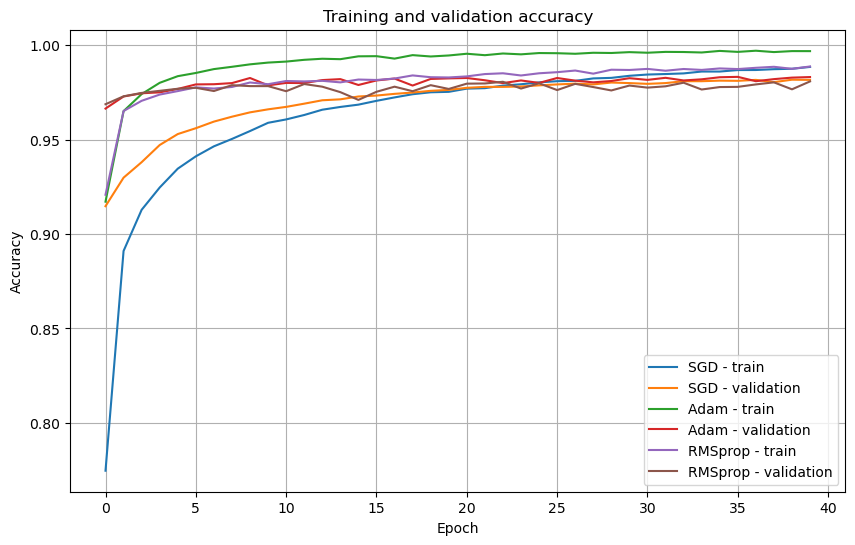

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(history_SGD.history["accuracy"], label="SGD - train")
plt.plot(history_SGD.history["val_accuracy"], label="SGD - validation")

plt.plot(history_Adam.history["accuracy"], label="Adam - train")
plt.plot(history_Adam.history["val_accuracy"], label="Adam - validation")

plt.plot(history_RMSprop.history["accuracy"], label="RMSprop - train")
plt.plot(history_RMSprop.history["val_accuracy"], label="RMSprop - validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid()
plt.show()

**Figure 1.** Comparison of the training and validation accuracy obtained with SGD, Adam, and RMSprop as a function of the number of epochs.

**Adam.** Adam achieves the highest training accuracy of the three optimizers, reaching $0.9969$ after $40$ epochs. The validation accuracy is already very high from the first epochs and shows only a small improvement during training. After reaching its saturation value, the curve fluctuates around it due to statistical noise, with a final validation accuracy of $0.9832$.

**SGD.** SGD reaches a lower final training accuracy of $0.9886$. Its validation accuracy reaches $0.9817$ after $40$ epochs. Compared with Adam, both training and validation curves are smoother and less affected by fluctuations, although the final performance is slightly worse.

**RMSprop.** RMSprop also starts with a high validation accuracy, which remains approximately constant throughout the training, with only small fluctuations due to statistical noise. The training accuracy follows a similar behaviour, reaching a plateau after the initial epochs. After $40$ epochs, RMSprop reaches a training accuracy of $0.9888$ and a validation accuracy of $0.9809$. 

Overall, Adam provides the highest final accuracy, while SGD shows the smoothest evolution of the training and validation curves.

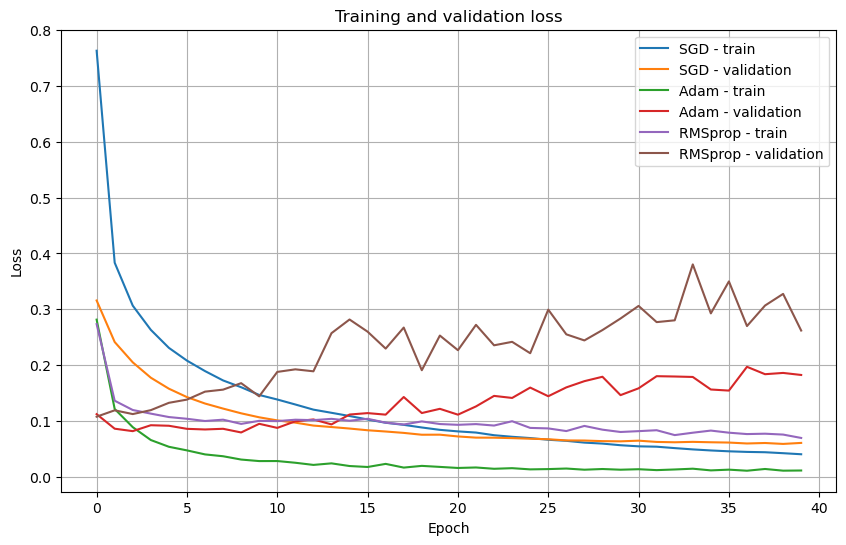

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(history_SGD.history["loss"], label="SGD - train")
plt.plot(history_SGD.history["val_loss"], label="SGD - validation")

plt.plot(history_Adam.history["loss"], label="Adam - train")
plt.plot(history_Adam.history["val_loss"], label="Adam - validation")

plt.plot(history_RMSprop.history["loss"], label="RMSprop - train")
plt.plot(history_RMSprop.history["val_loss"], label="RMSprop - validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid()
plt.show()

**Figure 2.** Comparison of the training and validation loss as a function of the number of epochs for SGD, Adam, and RMSprop. 

**Adam** achieves the lowest training loss, reaching $0.0116$ after $40$ epochs, but its validation loss increases and becomes increasingly noisy during training, reaching $0.1825$. 

**SGD** shows the most stable behaviour for both curves. Its validation loss remains lower than those obtained with Adam and RMSprop, reaching $0.0609$, while the training loss reaches $0.0406$. This indicates a more consistent generalization performance despite the higher training loss compared with Adam. 

**RMSprop** shows the highest training loss of the three optimizers, with a final value of $0.0698$, while its validation loss is also strongly affected by fluctuations and tends to increase with the number of epochs, reaching $0.2620$.

In [21]:
results = pd.DataFrame({
    "Optimizer": ["SGD", "Adam", "RMSprop"],
    "Test loss": [
        score_SGD[0],
        score_Adam[0],
        score_RMSprop[0]
    ],
    "Test accuracy": [
        score_SGD[1],
        score_Adam[1],
        score_RMSprop[1]
    ]
})

results

,Optimizer,Test loss,Test accuracy
0,SGD,0.060926,0.9817
1,Adam,0.182495,0.9832
2,RMSprop,0.261970,0.9809


### Conclusion

The three optimizers achieve a test accuracy of about 98%, with Adam reaching the highest final accuracy (98.32%). However, SGD shows a significantly lower test loss and a more stable validation behavior. In particular, the validation loss for SGD decreases throughout the training, whereas Adam and RMSprop exhibit stronger fluctuations and an overall increasing trend. Therefore, for the chosen network architecture and hyperparameters, SGD provides the most stable generalization performance, although Adam achieves a slightly higher final accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


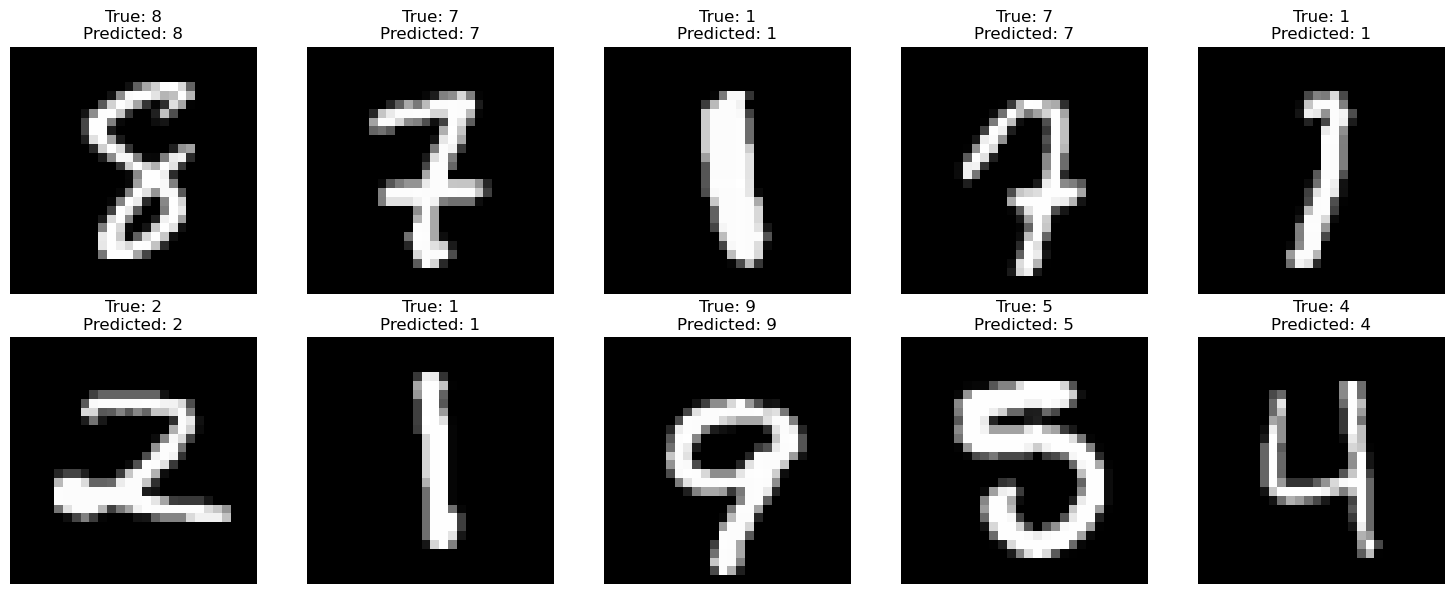

In [25]:
predictions = model_SGD.predict(X_test)

indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, index in enumerate(indices):
    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )

    true_label = np.argmax(Y_test[index])
    predicted_label = np.argmax(predictions[index])

    plt.title(
        f"True: {true_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


**Figure 3.** Ten images randomly selected from the MNIST test dataset are shown together with their true and predicted labels obtained using the trained neural network. All ten selected images are correctly classified, with the predicted digit matching the corresponding true label in every case. This provides a qualitative confirmation of the high classification accuracy achieved by the model on previously unseen data.

Number of misclassified images: 183


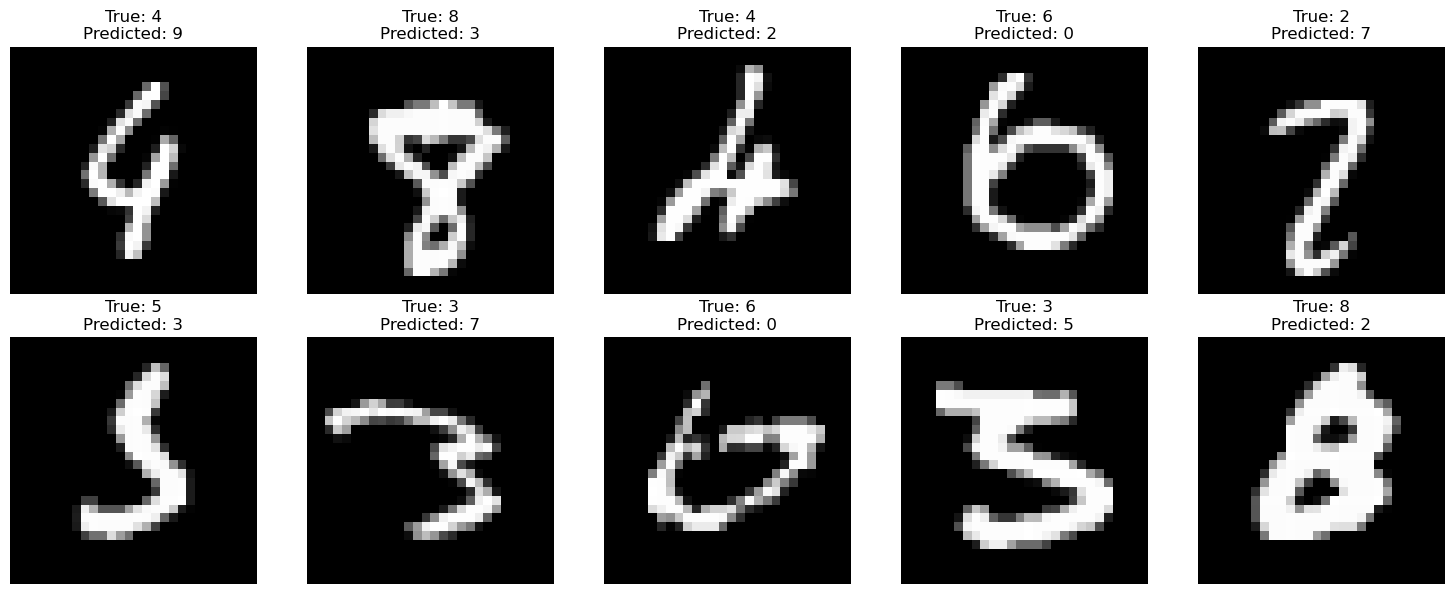

In [27]:
#Seraching for wrong predictions

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(Y_test, axis=1)

wrong_indices = np.where(predicted_labels != true_labels)[0]

print("Number of misclassified images:", len(wrong_indices))

plt.figure(figsize=(15, 6))

for i in range(10):
    index = wrong_indices[i]

    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {true_labels[index]}\n"
        f"Predicted: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Figure 4.** Ten images selected among the incorrectly classified samples in the MNIST test dataset are shown together with their true and predicted labels. Out of the entire test dataset, only $183$ images are incorrectly classified by the trained neural network. The selected examples illustrate the cases in which the visual similarity between different handwritten digits makes the classification task more challenging for the model.